# Lumber-Gold-Ratio — a quantitative teardown 🔬
### The rotation switch · an excess-of-cash race vs 60/40 / buy-and-hold / random rotation · HAC *t* + block-bootstrap CIs · costs · a synthetic planted-edge power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_60%2F40%3F: Busted](https://img.shields.io/badge/Beats_60%2F40%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The folk claim (Gayed & Bilello, 2015) is that the **lumber/gold ratio** is a leading risk-on/risk-off switch. We rebuild the tradable distillation — a binary SPY/TLT rotation keyed off the standardised log-ratio level — and confront it with the only question that matters: does the **timing** beat the passive mix and a same-exposure coin? The decisive object is not the switch's own Sharpe (a bond sleeve flatters it in a falling-rate regime) but the **HAC *t* that the switch's net excess return exceeds the 60/40 blend's**.

> ⚠️ **Data + proxy note.** Lumber futures (`LBS=F`) ended May 2023; we use the **WOOD** timber-equity ETF as a transparent **lumber proxy** (named on the Signal axis — it's an equity, so it *flatters* the risk-on read). Real data: yfinance daily adjusted closes — WOOD/GLD/SPY/TLT/^IRX, 2008→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lumber_gold_ratio import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
RACE = st.race(F, lookback=60, enter_z=0.0, cost_bps=5.0, rand_seed=388) if HAVE_REAL else None
print("real lumber/gold cache present:", HAVE_REAL,
      "| switch Sharpe:", (None if RACE is None else round(RACE["switch"]["sharpe_excess"], 2)),
      "| t vs 60/40:", (None if RACE is None else round(RACE["t_vs_6040"], 2)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-06-25', 'end': '2026-06-22', 'days': 4525, 'years': 18.0, 'n_switches': 609, 'switch': (5.21, 0.32, -59.5, 53.2, 1.43), 'buy_hold': (12.16, 0.61, -47.6, 100.0, 3.01), 'blend_6040': (9.36, 0.71, -27.2, 60.0, 3.24), 'random': (3.67, 0.22, -45.8, 53.2, 1.04), 't_vs_bh': -1.55, 't_vs_6040': -1.06, 't_vs_random': 0.25, 'ci_vs_6040': (-3.79, 1.15), 'ci_vs_random': (-2.65, 3.51), 'robust': [('lb=40,z>0', 0.35, -0.89, 0.36), ('lb=60,z>0', 0.32, -1.06, 0.25), ('lb=90,z>0', 0.36, -0.88, 1.75), ('lb=60,z>+0.5', 0.3, -1.19, 0.4), ('lb=60,z>-0.5', 0.54, 0.06, 0.59)], 'syn': [(0.0, -0.14, 0.56, 2.56), (0.15, 11.25, 41.11, 29.83)]}


real lumber/gold cache present: True | switch Sharpe: 0.32 | t vs 60/40: -1.06


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Switch Sharpe **0.32** vs static 60/40 **0.71**; HAC **t vs 60/40 = -1.06** (negative), **t vs random = +0.25** (dead heat). |
| **Tradability** | `MIRAGE` | **~609 whole-book rotations** / 18y for a book that under-performs the mix and draws down **-59.5%** (vs 60/40's **-27.2%**). |
| **Beats 60/40?** | `BUSTED` | Head-to-head daily-excess CI **[-3.79, +1.15] bps/day** straddles zero; no lookback/threshold flips *t* positive. |

> 💡 In plain words: the switch makes money (stocks and bonds both drift up), but the *timing* it adds is worthless — it loses to a set-and-forget 60/40 and ties a coin with the same average exposure. The synthetic control proves the test *has* power; the real tape has no edge to find.

## 1 · The claim, steelmanned

Let $L_t, G_t$ be the lumber-proxy and gold closes, $\rho_t = \log(L_t/G_t)$, and $z_t = (\rho_t - \mu_{t}^{(60)}) / \sigma_t^{(60)}$ its standardised deviation from a 60-day trailing mean. The **switch** sets next-day weight $w_{t+1} = \mathbb{1}[z_t > 0]$ in SPY (else TLT) — one execution lag, neutral 0.5 while warming up. The book earns $w\,r^{\text{SPY}} + (1-w)\,r^{\text{TLT}}$, minus $|\Delta w|\cdot c$ costs.

- **H₁ (the timing predicts).** The switch's excess-of-cash daily mean exceeds a static 60/40's: $\mathbb{E}[r^{\text{sw}}-r_f] > \mathbb{E}[r^{6040}-r_f]$.
- **H₂ (it's deployable).** Net of costs the edge survives at NAV scale with tolerable drawdown.
- **H₃ (it's *information*, not exposure).** The switch beats a **same-exposure random timer** — the ratio carries regime signal beyond the average beta it implies.

We find **H₁ rejected** (t vs 60/40 = −1.06, *negative*), **H₂ rejected** (~609 trades, −59.5% DD, under-performs the mix), **H₃ rejected** (t vs random = +0.25, a tie). The intermarket story is true as narrative and empty as timing.

## 2 · So what? — what rides on each answer

The whole teardown is one comparison of daily excess-of-cash return streams, judged by an **autocorrelation-robust** standard error:

$$\widehat{\Delta} = \overline{(r^{\text{sw}}-r_f) - (r^{\text{bench}}-r_f)},\qquad t_{\text{HAC}} = \frac{\widehat{\Delta}}{\widehat{\mathrm{se}}_{\text{NW}}(\widehat{\Delta})}.$$

A raw Sharpe is the wrong lens: a switch that parks in **TLT** through a falling-rate decade books a flattering bond Sharpe that has nothing to do with the *ratio*. The honest bench is the **static 60/40** (same asset menu, zero timing) and the **same-exposure random timer** (same average beta, zero information). Newey-West corrects the SE for the heavy daily autocorrelation; a **circular block bootstrap** puts a CI on the mean daily difference. Those two head-to-heads, not the switch's own Sharpe, decide the Signal axis.

## 3 · How we'd know — the protocol

- **Real tape.** yfinance adjusted closes — WOOD (lumber proxy), GLD, SPY, TLT, ^IRX (cash), 2008-06-25→2026-06-22, 4,525 days. WOOD is an explicit **proxy** (LBS=F futures discontinued May 2023), named on the axis.
- **Signal.** $z_t$ = standardised 60-day deviation of the log WOOD/GLD ratio, known at the close of *t*.
- **Switch.** $w_{t+1}=\mathbb{1}[z_t>0]$ in SPY else TLT; **one** execution lag; neutral 0.5 during warm-up (no look-ahead, no directional bet without signal).
- **Race.** vs buy-and-hold SPY, a **static 60/40**, and a **same-exposure random timer** (same count of bond days on *random* days, seeded).
- **Costs.** 5 bps one-way × NAV on every rotation ($|\Delta w|$ turnover).
- **Inference.** Newey-West **HAC t** on the daily excess-of-cash difference + a **circular block bootstrap** (block 21, 2000 draws) CI.
- **Control.** A deterministic tape with a planted forward link `pred_r` between the lagged z-score and the next-day equity-minus-bond spread: `pred_r=0` is the null, `pred_r>0` the folklore-consistent positive control.

## 4 · The teardown

### 4a · The race — risk-adjusted, above cash, net of costs

Sharpe (excess-of-cash) for all four books. The switch must clear the **static 60/40**; it doesn't come close.

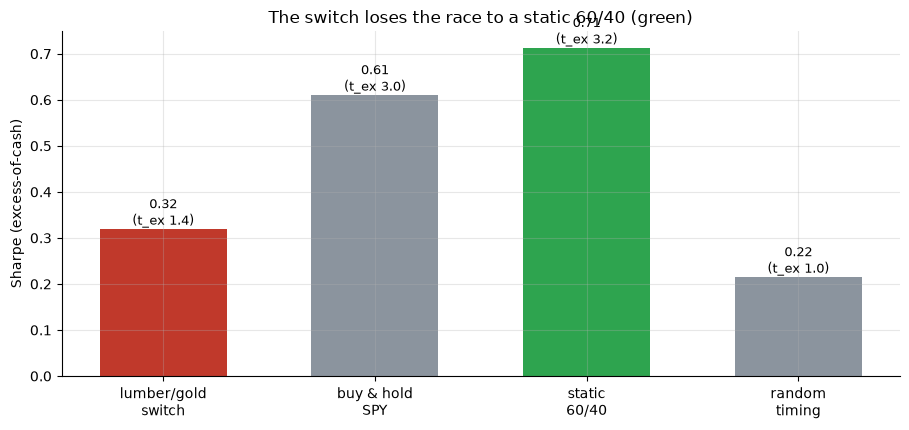

Sharpe — switch 0.32 | 60/40 0.71 | random 0.22


In [2]:
keys = ['switch', 'buy_hold', 'blend_6040', 'random']
labels = ['lumber/gold\nswitch', 'buy & hold\nSPY', 'static\n60/40', 'random\ntiming']
if HAVE_REAL:
    sh = [RACE[k]['sharpe_excess'] for k in keys]
    te = [RACE[k]['t_excess'] for k in keys]
else:
    sh = [R[k][1] for k in keys]; te = [R[k][4] for k in keys]
x = np.arange(len(keys))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, sh, color=[RED, GREY, GREEN, GREY], width=.6)
for i,(v,t) in enumerate(zip(sh,te)): ax.annotate(f'{v:.2f}\n(t_ex {t:.1f})',(i,v),ha='center',va='bottom',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Sharpe (excess-of-cash)')
ax.set_title('The switch loses the race to a static 60/40 (green)')
plt.tight_layout(); plt.show()
print('Sharpe — switch', round(sh[0],2), '| 60/40', round(sh[2],2), '| random', round(sh[3],2))

> 💡 In plain words: the switch's own Sharpe is **0.32** — *below* the static **60/40**'s **0.71** and barely above the random timer's **0.22**. Even buy-and-hold SPY beats it on raw return. The clever flipping is destroying value, not adding it.

### 4b · The decisive head-to-heads — HAC *t* and bootstrap CIs

The switch's **net excess-of-cash daily return minus the benchmark's**, with a Newey-West *t* and a circular block-bootstrap 95% CI (bps/day). For an edge we need a *positive* *t* clearing 2 against 60/40 **and** against random.

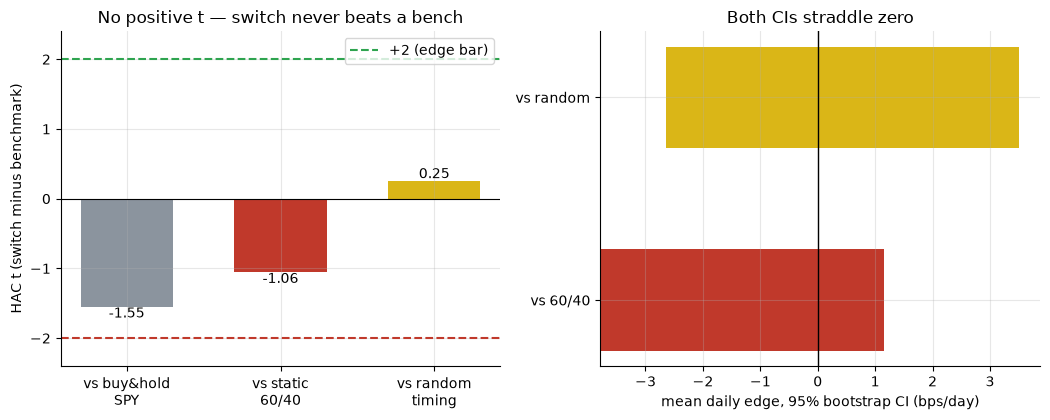

t vs 60/40 -1.06 | t vs random 0.25 | CI vs 60/40 (bps/day) (-3.79, 1.15)


In [3]:
if HAVE_REAL:
    tv = [RACE['t_vs_bh'], RACE['t_vs_6040'], RACE['t_vs_random']]
    ci6 = RACE['ci_vs_6040']; cir = RACE['ci_vs_random']
    ci6 = (ci6[0]*1e4, ci6[1]*1e4); cir = (cir[0]*1e4, cir[1]*1e4)
else:
    tv = [R['t_vs_bh'], R['t_vs_6040'], R['t_vs_random']]
    ci6 = R['ci_vs_6040']; cir = R['ci_vs_random']
labs = ['vs buy&hold\nSPY', 'vs static\n60/40', 'vs random\ntiming']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(labs, tv, color=[GREY, RED, AMBER], width=.6)
a1.axhline(2, ls='--', c=GREEN, label='+2 (edge bar)'); a1.axhline(-2, ls='--', c=RED)
a1.axhline(0, c='k', lw=.8)
for i,t in enumerate(tv): a1.annotate(f'{t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
a1.set_ylabel('HAC t (switch minus benchmark)'); a1.set_ylim(-2.4, 2.4)
a1.set_title('No positive t — switch never beats a bench'); a1.legend()
a2.barh(['vs 60/40','vs random'], [ci6[1]-ci6[0], cir[1]-cir[0]],
        left=[ci6[0], cir[0]], color=[RED, AMBER], height=.5)
a2.axvline(0, c='k', lw=1)
a2.set_xlabel('mean daily edge, 95% bootstrap CI (bps/day)')
a2.set_title('Both CIs straddle zero')
plt.tight_layout(); plt.show()
print('t vs 60/40', round(tv[1],2), '| t vs random', round(tv[2],2),
      '| CI vs 60/40 (bps/day)', tuple(round(c,2) for c in ci6))

> 💡 In plain words: against the **60/40** the *t* is **-1.06** — *negative* — and the CI **[-3.79, +1.15] bps/day** straddles zero. Against the **random** timer it's **+0.25**, a textbook tie. H₁ and H₃ both rejected: the lumber/gold ratio carries **no** timing information beyond the average exposure it happens to imply.

### 4c · Robustness — no lookback or threshold rescues it

Sweep the lookback and entry threshold. The *t* vs 60/40 is negative-or-zero everywhere; the *t* vs random never clears 2. The only Sharpe-lifting config (z>−0.5) is just *hold stocks almost always* — no longer a rotation.

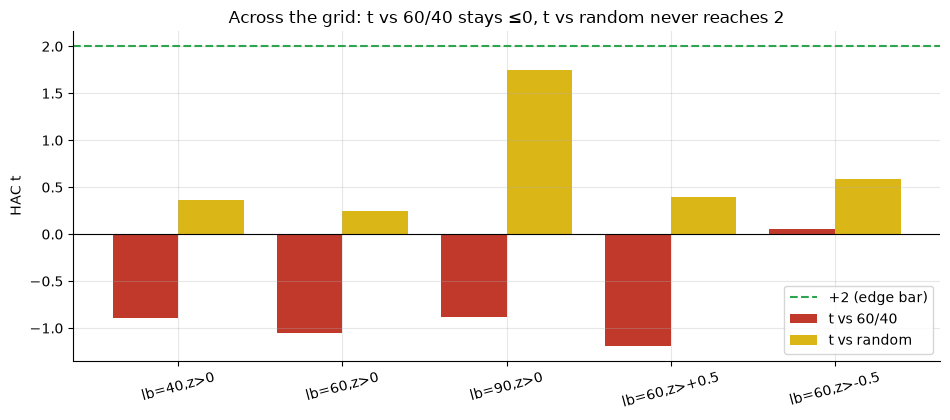

robustness (label, sharpe, t_vs_6040, t_vs_random):
   lb=40,z>0 0.35 -0.89 0.36
   lb=60,z>0 0.32 -1.06 0.25
   lb=90,z>0 0.36 -0.88 1.75
   lb=60,z>+0.5 0.3 -1.19 0.4
   lb=60,z>-0.5 0.54 0.06 0.59


In [4]:
if HAVE_REAL:
    rob = []
    for lb, ez, lab in [(40,0.0,'lb=40,z>0'),(60,0.0,'lb=60,z>0'),(90,0.0,'lb=90,z>0'),
                        (60,0.5,'lb=60,z>+0.5'),(60,-0.5,'lb=60,z>-0.5')]:
        r2 = st.race(F, lookback=lb, enter_z=ez, cost_bps=5.0, rand_seed=388)
        rob.append((lab, r2['switch']['sharpe_excess'], r2['t_vs_6040'], r2['t_vs_random']))
else:
    rob = R['robust']
labs = [r[0] for r in rob]; t6 = [r[2] for r in rob]; tr = [r[3] for r in rob]
x = np.arange(len(rob))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.2, t6, .4, color=RED, label='t vs 60/40')
ax.bar(x+.2, tr, .4, color=AMBER, label='t vs random')
ax.axhline(2, ls='--', c=GREEN, label='+2 (edge bar)'); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labs, rotation=15); ax.set_ylabel('HAC t')
ax.set_title('Across the grid: t vs 60/40 stays ≤0, t vs random never reaches 2'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (label, sharpe, t_vs_6040, t_vs_random):')
for r in rob: print('  ', r[0], round(r[1],2), round(r[2],2), round(r[3],2))

> 💡 In plain words: there is no corner of the parameter grid where the *timing* adds value. Loosening to **z>−0.5** lifts the Sharpe only because it parks you in stocks ~90% of the time — riding the SPY drift, not rotating — and it *still* ties random (t = 0.59). The result is not a tuning artefact; it's the absence of an edge.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic tape with a planted forward link `pred_r` (lagged z-score → next-day equity-minus-bond spread). With `pred_r=0` (no link) the decisive *t* vs 60/40 must stay small; with `pred_r=+0.15` (folklore-consistent) it must light up. Both hold — so the engine is unbiased *and* has power; the flat real-tape result is no-edge, not no-power.

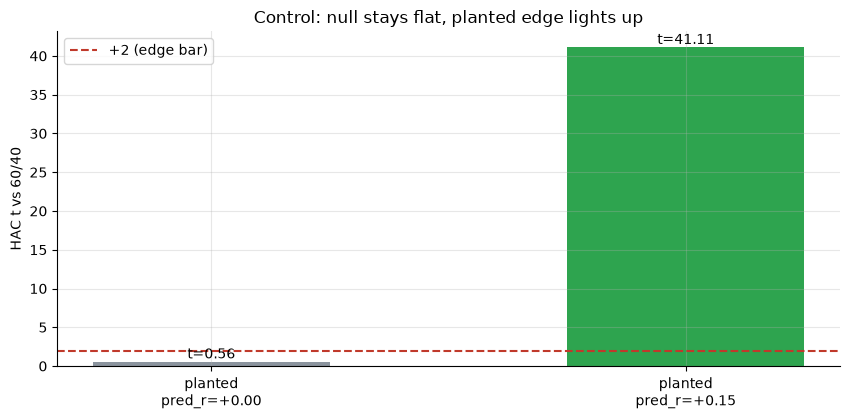

pred_r=+0.00: switch Sharpe  -0.14  t_vs_6040    0.56  t_vs_random   2.56
pred_r=+0.15: switch Sharpe  11.25  t_vs_6040   41.11  t_vs_random  29.83


In [5]:
res = []
for pr in (0.0, 0.15):
    syn, _ = data.synthetic_daily(n_days=4000, pred_r=pr, seed=388)
    rs = st.race(syn, lookback=60, enter_z=0.0, cost_bps=5.0, rand_seed=388)
    res.append((pr, rs['switch']['sharpe_excess'], rs['t_vs_6040'], rs['t_vs_random']))
labels = [f'planted\npred_r={pr:+.2f}' for pr,_,_,_ in res]
t6 = [r[2] for r in res]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, t6, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='+2 (edge bar)')
for i,t in enumerate(t6): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('HAC t vs 60/40'); ax.set_title('Control: null stays flat, planted edge lights up')
ax.legend(); plt.tight_layout(); plt.show()
for pr,s,t6v,trv in res: print(f'pred_r={pr:+.2f}: switch Sharpe {s:6.2f}  t_vs_6040 {t6v:7.2f}  t_vs_random {trv:6.2f}')

> 💡 In plain words: with **no** planted link the decisive *t* vs 60/40 sits at **+0.56** (flat — no false positive); plant a folklore-consistent edge and the same machinery slams to **t = 41**. So the test would *easily* find a real lumber/gold timing edge. On the real tape it finds **-1.06**: not a power problem — an *edge* problem.

## 5 · The verdict

- **Signal `NONE`** — switch Sharpe **0.32** vs static 60/40 **0.71**; HAC **t vs 60/40 = -1.06** (negative), **t vs random = +0.25** (tie). The control proves the test has power, so this is the absence of an edge, not the absence of data. No REAL.
- **Tradability `MIRAGE`** — **~609 whole-book rotations / 18y** for a book that under-performs the passive mix and draws down **-59.5%** (twice the 60/40's). Nothing to allocate to.
- **Beats 60/40? `BUSTED`** — the head-to-head daily-excess CI **[-3.79, +1.15] bps/day** straddles zero and no lookback/threshold flips the *t* positive. The intermarket *timing* loses to the blend it is meant to beat.

## 6 · Could you trade it? — the drawdown picture

The operational truth in one chart: a *defensive* switch should fall *less* than its benchmarks in a crash. Here are the equity curves and their worst falls — the switch falls the **farthest**.

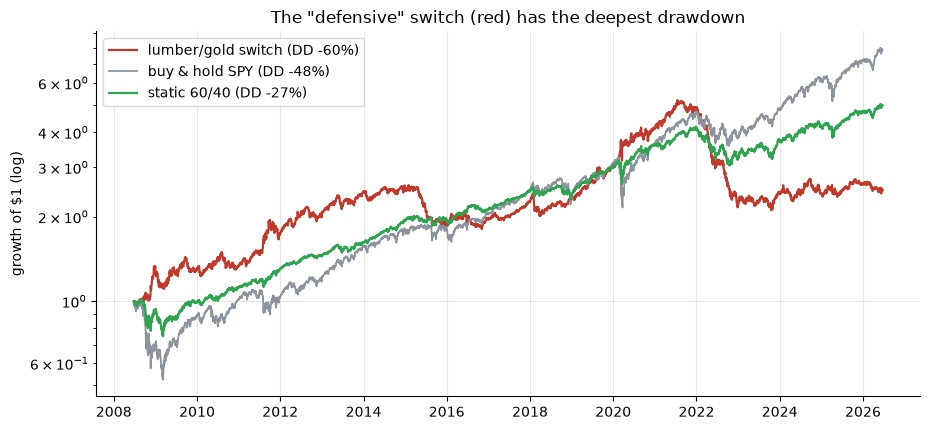

worst falls — switch -59.5 | 60/40 -27.2


In [6]:
if HAVE_REAL:
    import pandas as pd
    pos = st.switch_positions(F, lookback=60, enter_z=0.0)
    sw = st.book_returns(F, pos, cost_bps=5.0)['r_net']
    bh = F['equity'].pct_change().fillna(0.0)
    blend = 0.6*F['equity'].pct_change().fillna(0.0) + 0.4*F['bond'].pct_change().fillna(0.0)
    def curve(r): return (1+r).cumprod()
    fig, ax = plt.subplots(figsize=(9.4, 4.4))
    ax.plot(curve(sw).index, curve(sw).values, c=RED, lw=1.6, label=f'lumber/gold switch (DD {RACE["switch"]["max_dd"]*100:.0f}%)')
    ax.plot(curve(bh).index, curve(bh).values, c=GREY, lw=1.3, label=f'buy & hold SPY (DD {RACE["buy_hold"]["max_dd"]*100:.0f}%)')
    ax.plot(curve(blend).index, curve(blend).values, c=GREEN, lw=1.6, label=f'static 60/40 (DD {RACE["blend_6040"]["max_dd"]*100:.0f}%)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('The "defensive" switch (red) has the deepest drawdown'); ax.legend()
    plt.tight_layout(); plt.show()
    print('worst falls — switch', round(RACE['switch']['max_dd']*100,1), '| 60/40', round(RACE['blend_6040']['max_dd']*100,1))
else:
    print('no cache — frozen DDs: switch', R['switch'][2], '| 60/40', R['blend_6040'][2])

> 💡 In plain words: the switch's worst fall is **-59.5%** — *deeper* than buy-and-hold SPY (**-47.6%**) and more than double the static 60/40's (**-27.2%**). The ratio repeatedly held bonds into rallies and stocks into routs. A defensive rule that amplifies drawdowns and ~600 rotations of cost is the anti-strategy: all the trading, none of the protection.

## 7 · Going further

- **The cousins.** [Study 305 — Gold-Oil-Ratio](../../305-gold-oil-ratio/) and [Study 85 — Dr Copper](../../85-dr-copper/) — the same cyclical-commodity-leads-the-economy construct; [Study 113 — Gold-Silver-Ratio](../../113-gold-silver-ratio/) the within-metals sibling.
- **The yardstick family.** [Study 144 — Permanent-Portfolio](../../144-permanent-portfolio/) — the passive static mixes any intermarket *timing* rule must beat.
- **Harder versions.** Replace WOOD with the short `LBR` lumber future or a spliced LBS=F→LBR series, add a vol-target overlay, or test a copper/gold variant; the proxy and the overlay change, the absent-timing-edge does not.

*The reproducible core is offline and deterministic; lumber is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*